# PCA — Метод главных компонент

**Principal Component Analysis (PCA)** — линейный метод сокращения размерности. Он проецирует данные на ортогональные оси — **главные компоненты**, — упорядоченные по убыванию объяснённой дисперсии. Математически PCA сводится к нахождению собственных векторов ковариационной матрицы. Позволяет сократить сотни коррелированных признаков до нескольких информативных компонент без значительной потери информации.

**Датасет:** Human Activity Recognition — данные сенсоров смартфона (561 признак) при 6 видах активности.

## 2. Используемые библиотеки

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

## 3. Описание и демонстрация датасета

In [2]:
train = pd.read_csv('./train.csv')
test  = pd.read_csv('./test.csv')
df    = pd.concat([train, test], ignore_index=True)

activity_map = {1:'Walking', 2:'Walking Upstairs', 3:'Walking Downstairs',
                4:'Sitting', 5:'Standing', 6:'Laying'}
df['Activity_name'] = df['Activity'].map(activity_map)

print("Форма датасета (train+test):", df.shape)
print(f"Число признаков (без меток): {df.shape[1]-2}")
print("\nПервые 5 строк (первые 8 признаков):")
print(df.iloc[:5, :8].round(4).to_string())
print("\nРаспределение активностей:")
print(df['Activity_name'].value_counts())

Форма датасета (train+test): (10299, 564)
Число признаков (без меток): 562

Первые 5 строк (первые 8 признаков):
   tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  tBodyAcc-std()-X  tBodyAcc-std()-Y  tBodyAcc-std()-Z  tBodyAcc-mad()-X  tBodyAcc-mad()-Y
0             0.2886            -0.0203            -0.1329           -0.9953           -0.9831           -0.9135           -0.9951           -0.9832
1             0.2784            -0.0164            -0.1235           -0.9982           -0.9753           -0.9603           -0.9988           -0.9749
2             0.2797            -0.0195            -0.1135           -0.9954           -0.9672           -0.9789           -0.9965           -0.9637
3             0.2792            -0.0262            -0.1233           -0.9961           -0.9834           -0.9907           -0.9971           -0.9827
4             0.2766            -0.0166            -0.1154           -0.9981           -0.9808           -0.9905           -0.9983           -

## 4. Предварительная обработка

In [3]:
from sklearn.preprocessing import LabelEncoder

X = df.drop(['Activity', 'Activity_name', 'subject'], axis=1, errors='ignore').values

le = LabelEncoder()
y  = le.fit_transform(df['Activity'].astype(str).values)
activity_map  = {i: name for i, name in enumerate(le.classes_)}
labels_names  = list(le.classes_)

print("Классы активностей:", labels_names)
print(f"Размерность признаков: {X.shape}")
print("Пропущенные значения:", np.isnan(X).sum())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"\nПосле масштабирования: mean≈{X_scaled.mean():.4f}, std≈{X_scaled.std():.4f}")

Классы активностей: ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']
Размерность признаков: (10299, 561)
Пропущенные значения: 0

После масштабирования: mean≈0.0000, std≈1.0000


## 5. Средние значения признаков

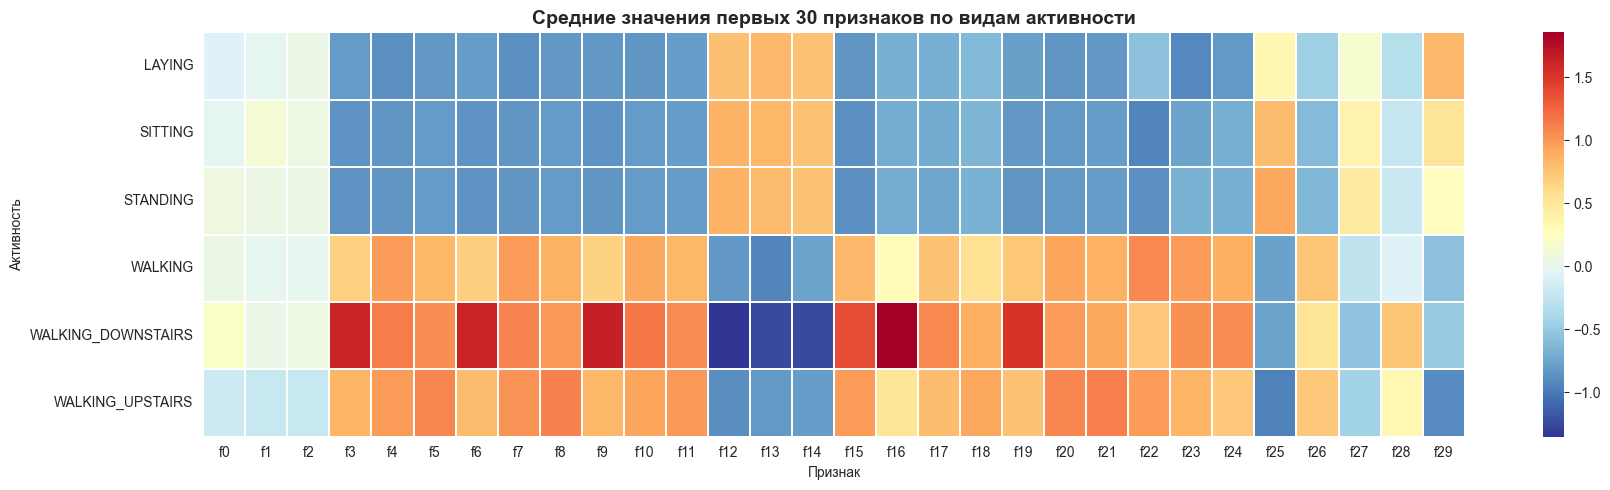

In [4]:
# Тепловая карта: средние признаки по активностям (первые 30)
df_feat = pd.DataFrame(X_scaled[:, :30], columns=[f'f{i}' for i in range(30)])
df_feat['activity'] = [activity_map[a] for a in y]
heatmap_data = df_feat.groupby('activity').mean()

plt.figure(figsize=(18, 5))
sns.heatmap(heatmap_data, cmap='RdYlBu_r', linewidths=0.2)
plt.title('Средние значения первых 30 признаков по видам активности', fontsize=14, fontweight='bold')
plt.ylabel('Активность'); plt.xlabel('Признак')
plt.tight_layout(); plt.show()

## 6. Обучение PCA — дисперсия от числа компонент

80% дисперсии → 27 компонент из 561
90% дисперсии → 65 компонент из 561
95% дисперсии → 104 компонент из 561
99% дисперсии → 182 компонент из 561


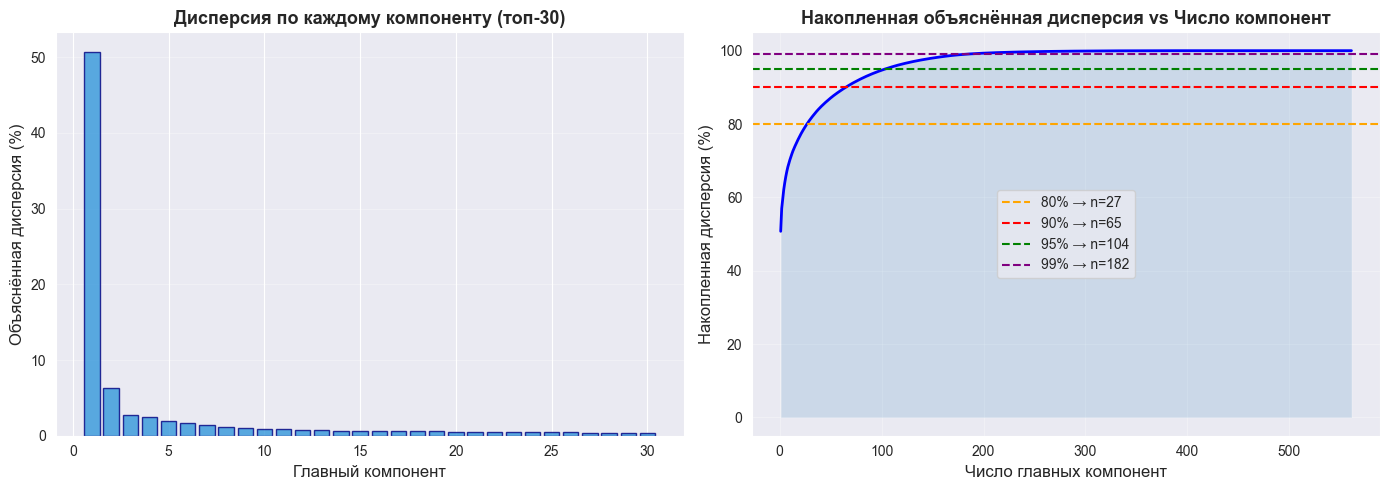

In [5]:
# Полный PCA
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

explained     = pca_full.explained_variance_ratio_
cumulative    = np.cumsum(explained)

for thr in [0.80, 0.90, 0.95, 0.99]:
    n = np.argmax(cumulative >= thr) + 1
    print(f"{int(thr*100)}% дисперсии → {n} компонент из {X.shape[1]}")

# ── Графики дисперсии ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 31), explained[:30]*100, color='#3498DB', alpha=0.8, edgecolor='navy')
axes[0].set_xlabel('Главный компонент', fontsize=12)
axes[0].set_ylabel('Объяснённая дисперсия (%)', fontsize=12)
axes[0].set_title('Дисперсия по каждому компоненту (топ-30)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].plot(range(1, len(cumulative)+1), cumulative*100, 'b-', linewidth=2)
for thr, col, label in [(80,'orange','80%'), (90,'red','90%'), (95,'green','95%'), (99,'purple','99%')]:
    n_comp = np.argmax(cumulative >= thr/100) + 1
    axes[1].axhline(y=thr, color=col, linestyle='--', label=f'{label} → n={n_comp}')
axes[1].fill_between(range(1, len(cumulative)+1), cumulative*100, alpha=0.15)
axes[1].set_xlabel('Число главных компонент', fontsize=12)
axes[1].set_ylabel('Накопленная дисперсия (%)', fontsize=12)
axes[1].set_title('Накопленная объяснённая дисперсия vs Число компонент', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [6]:
# PCA с разным числом компонент + классификация для оценки потерь
results_cls = []
for n in [2, 5, 10, 20, 50, 100, 200, X.shape[1]]:
    pca_n = PCA(n_components=n, random_state=42)
    X_n = pca_n.fit_transform(X_scaled)
    clf = LogisticRegression(max_iter=200, random_state=42)
    # Простое разбиение
    split = int(len(X_n)*0.8)
    clf.fit(X_n[:split], y[:split])
    acc = accuracy_score(y[split:], clf.predict(X_n[split:]))
    var = pca_n.explained_variance_ratio_.sum()*100
    results_cls.append({'n_components': n, 'variance_%': round(var,1), 'accuracy': round(acc,4)})

print("Точность LogReg при разном числе компонент:")
print(pd.DataFrame(results_cls).to_string(index=False))

Точность LogReg при разном числе компонент:
 n_components  variance_%  accuracy
            2        57.0    0.5786
            5        64.0    0.8102
           10        70.2    0.8495
           20        76.8    0.8835
           50        87.1    0.9228
          100        94.7    0.9422
          200        99.3    0.9612
          561       100.0    0.9636


## 7. Прогнозы — проекция и нагрузки

In [7]:
pca_2 = PCA(n_components=2, random_state=42)
X_2d  = pca_2.fit_transform(X_scaled)

df_2d = pd.DataFrame(X_2d, columns=['PC1','PC2'])
df_2d['activity'] = [activity_map[a] for a in y]
print("2D-проекция (первые 10 строк):")
print(df_2d.head(10).round(4).to_string())

# Реконструкция
pca_50 = PCA(n_components=50, random_state=42)
X_50 = pca_50.fit_transform(X_scaled)
X_rec = pca_50.inverse_transform(X_50)
mse = np.mean((X_scaled - X_rec)**2)
print(f"\nОшибка реконструкции (MSE, PCA-50): {mse:.6f}")

2D-проекция (первые 10 строк):
       PC1     PC2  activity
0 -16.3810  1.9951  STANDING
1 -15.5822  1.1826  STANDING
2 -15.4240  2.2432  STANDING
3 -15.6478  3.7629  STANDING
4 -15.8423  4.4389  STANDING
5 -15.6448  4.6202  STANDING
6 -15.1816  3.0059  STANDING
7 -15.5072  1.9280  STANDING
8 -15.7765  3.0888  STANDING
9 -14.3699  2.4371  STANDING

Ошибка реконструкции (MSE, PCA-50): 0.129010


## 8. Графики результатов

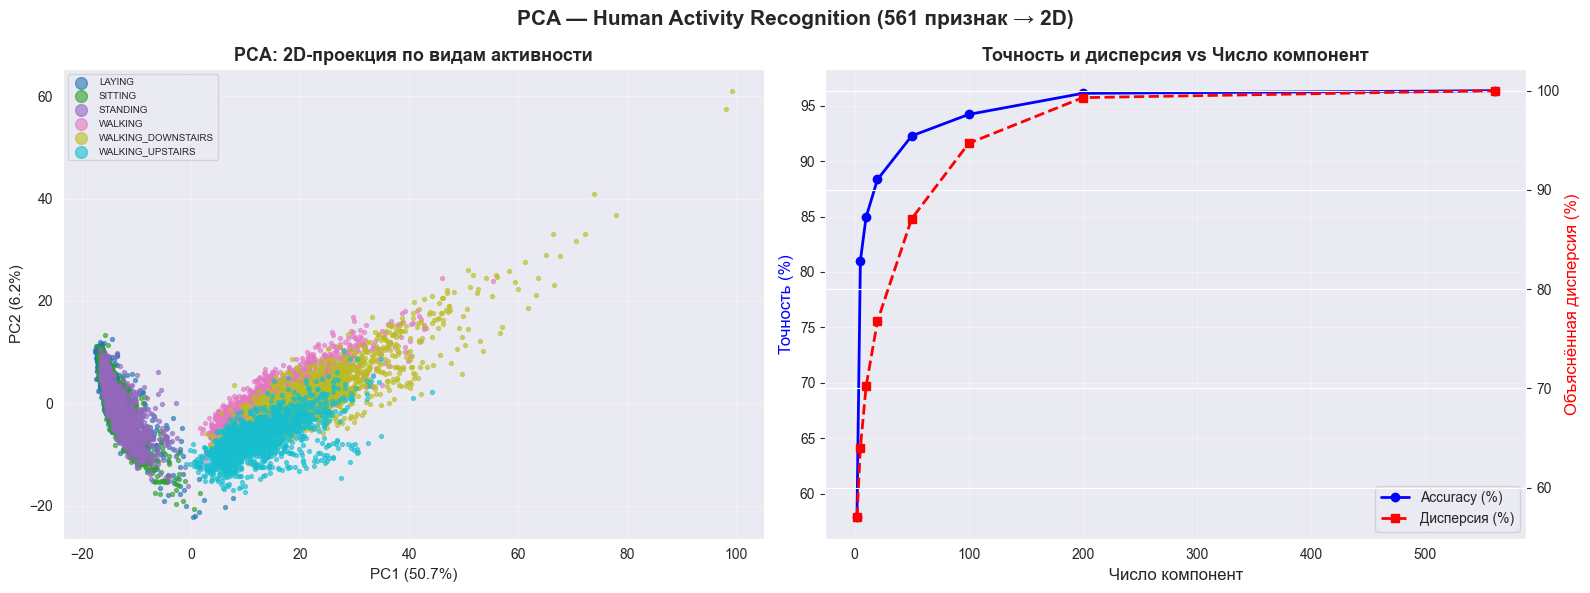

In [8]:
import matplotlib.cm as cm
palette = cm.tab10(np.linspace(0, 1, 6))
activities = sorted(df_2d['activity'].unique())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 2D PCA scatter
for i, act in enumerate(activities):
    mask = df_2d['activity'] == act
    axes[0].scatter(X_2d[mask,0], X_2d[mask,1], c=[palette[i]], s=8, alpha=0.6, label=act)
axes[0].set_xlabel(f'PC1 ({pca_2.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca_2.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
axes[0].set_title('PCA: 2D-проекция по видам активности', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=7, markerscale=3); axes[0].grid(True, alpha=0.3)

# Accuracy vs n_components
res = pd.DataFrame(results_cls)
ax2 = axes[1]
ax2.plot(res['n_components'], res['accuracy']*100, 'bo-', linewidth=2, markersize=6, label='Accuracy (%)')
ax2b = ax2.twinx()
ax2b.plot(res['n_components'], res['variance_%'], 'rs--', linewidth=2, markersize=6, label='Дисперсия (%)')
ax2.set_xlabel('Число компонент', fontsize=12)
ax2.set_ylabel('Точность (%)', color='blue', fontsize=12)
ax2b.set_ylabel('Объяснённая дисперсия (%)', color='red', fontsize=12)
axes[1].set_title('Точность и дисперсия vs Число компонент', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1+lines2, labels1+labels2, fontsize=10)

plt.suptitle('PCA — Human Activity Recognition (561 признак → 2D)', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()